# Heterogeneous DID via two-stage differences in differences (Gardner, 2021)

![](https://carlos-mendez.org/project/r_two_stage_did/featured_huf4be0386abdc0d2988621e93ba72b1c7_230089_720x0_resize_lanczos_2.png)

**Acknowledgment**: This tutorial is based on the excellent article by Butts, K., & Gardner, J. (2022), titled ["did2s: Two-Stage Difference-in-Differences,"](https://www.kylebutts.com/papers/did2s/) published in the R Journal, 14(3).

In [ ]:
# @title Watch the video
install.packages('IRdisplay')
library(IRdisplay)
# URL of the YouTube video
video_url <- "https://www.youtube.com/embed/6mVfQkmpghY"

# HTML code to embed the video
embed_code <- paste0('<iframe width="560" height="315" src="', video_url, '" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>')

# Display the embedded video
display_html(embed_code)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




[Watch the video on YouTube](https://youtu.be/6mVfQkmpghY?si=FaaaD6YOhw579PJ8)





## Homogeneous Treatment Effects

- 🎯 **Purpose**:
  Estimates treatment effects when the treatment is not randomly assigned.
- 📉 **Parallel Trends Assumption**:
  Assumes that in the absence of treatment, the treated and untreated groups would have followed parallel paths over time.
- 🔄 **Two-Way Fixed-Effects (TWFE) Model**:
  - **Static Model**:

  $$
  y_{igt} = \mu_g + \eta_t + \tau D_{gt} + \epsilon_{igt}
  $$

    - $ y_{igt} $: Outcome variable.
    - $ i $: Individual.
    - $ t $: Time.
    - $ g $: Group.
    - $ \mu_g $: Group fixed-effects.
    - $ \eta_t $: Time fixed-effects.
    - $ D_{gt} $: Indicator for treatment status.
    - $ \tau $: Average treatment effect on the treated (ATT).
- ❗ **Limitations**:
  Assumes constant treatment effects across groups and time, which is often unrealistic.


## Heterogeneous Treatment Effects

- 🔄 **Enhanced TWFE Model**:
  $$
  y_{igt} = \mu_g + \eta_t + \tau_{gt} D_{gt} + \epsilon_{igt}
  $$
  - Allows treatment effects ($ \tau_{gt} $) to vary by group and time.
  - Aggregates group-time average treatment effects into an overall average treatment effect ($ \tau $).


## Dynamic Event-Study TWFE Model

- 🔄 **Model**:
  $$
  y_{igt} = \mu_g + \eta_t + \sum_{k=-L}^{-2} \tau_k D_{gt}^k + \sum_{k=0}^{K} \tau_k D_{gt}^k + \epsilon_{igt}
  $$
  - Allows for treatment effects to change over time.
  - $ D_{gt}^k $: Lags and leads of treatment status.
  - Coefficients ($ \tau_k $) represent the average effect of being treated for $ k $ periods.

- 🎯 **Estimation Goals**:
  - **Objective**: Estimate the average treatment effect of being exposed for $ k $ periods.
  - **Average Treatment Effect**:
    $$
    \tau_k = \sum_{g,t : t-g=k} \frac{N_{gt}}{N_k} \tau_{gt}
    $$
    - $ N_{gt} $: Number of observations in group $ g $ and time $ t $.
    - $ N_k $: Total number of observations with $ t - g = k $.

## Negative Weighting Problem

- ❗ **Issue**: Traditional TWFE models can produce estimates with negative weights, leading to biased overall treatment effect estimates.
- 🛠 **Solution by Gardner (2022)**:
  - Use a two-stage approach to estimate group and time fixed-effects from untreated/not-yet-treated observations and then estimate treatment effects using residualized outcomes.


## Two-stage differences in differences

- 🌱 **Gardner (2022) Approach**:

  - 🔍 **Key Insight**: Under parallel trends, group and time effects are identified from the untreated/not-yet-treated observations.

  - 📜 **Procedure**:

    1. 🥇 **First Stage**:

       - Estimate the model:

         \begin{equation}
         y_{igt} = \mu_g + \eta_t + \epsilon_{igt}
         \end{equation}

       - Using only untreated/not-yet-treated observations ($D_{gt} = 0$).
       - Obtain estimates for group and time effects ($\mu_g$ and $\eta_t$).

    2. 🥈 **Second Stage**:

       - Regress adjusted outcomes ($y_{igt} - \mu_g - \eta_t$) on treatment status ($D_{gt}$) in the full sample to estimate treatment effects ($\tau$).

  - 🎯 **Rationale**:

    - The parallel trends assumption implies that residuals ($\epsilon_{igt}$) are uncorrelated with the treatment dummy, leading to a consistent estimator for the average treatment effect.

## Inference

- 📉 **Adjusting Standard Errors**:
  - The standard variance-covariance matrix from the second-stage regression is incorrect as it doesn't account for the first-stage estimation error.
  - 📊 **Generalized Method of Moments (GMM)**:
    - Two-stage GMM estimator is used to obtain correct standard errors.

## Example
Based on:
- https://kylebutts.github.io/did2s/articles/Two-Stage-Difference-in-Differences.html
- https://kylebutts.github.io/did2s/articles/event_study.html
- https://github.com/kylebutts/did2s
- https://github.com/kylebutts/did2s_stata
- https://www.kylebutts.com/papers/did2s/

### Setup

In [1]:
install.packages("did2s")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘Deriv’, ‘microbenchmark’, ‘doBy’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘zoo’, ‘Formula’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘trust’, ‘plyr’, ‘numDeriv’, ‘sandwich’, ‘dreamerr’, ‘stringmagic’, ‘RhpcBLASctl’, ‘float’, ‘BMisc’, ‘pbapply’, ‘ggpubr’, ‘DRDID’, ‘reshape2’, ‘coop’, ‘RcppEigen’, ‘RcppArmadillo’, ‘fixest’, ‘SparseM’, ‘MatrixExtra’, ‘did’, ‘staggered’, ‘didimputation’




In [2]:
library(did2s)
library(ggplot2)
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)  # Adjust the width and height as needed

Loading required package: fixest

did2s (v1.0.2). For more information on the methodology, visit <https://www.kylebutts.github.io/did2s>

To cite did2s in publications use:

  Butts, Kyle (2021).  did2s: Two-Stage Difference-in-Differences
  Following Gardner (2021). R package version 1.0.2.

A BibTeX entry for LaTeX users is

  @Manual{,
    title = {did2s: Two-Stage Difference-in-Differences Following Gardner (2021)},
    author = {Kyle Butts},
    year = {2021},
    url = {https://github.com/kylebutts/did2s/},
  }





In [3]:
#help(did2s)

### Load and explore the data

In [4]:
data(df_het, package = "did2s")

In [5]:
df_het

unit,state,group,unit_fe,g,year,year_fe,treat,rel_year,rel_year_binned,error,te,te_dynamic,dep_var
<int>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,33,Group 2,7.043016,2010,1990,0.066158886,FALSE,-20,-6,-0.08646599,0,0.00,7.022709
1,33,Group 2,7.043016,2010,1991,-0.030980320,FALSE,-19,-6,0.76659269,0,0.00,7.778628
1,33,Group 2,7.043016,2010,1992,-0.119607425,FALSE,-18,-6,1.51296819,0,0.00,8.436377
1,33,Group 2,7.043016,2010,1993,0.126321462,FALSE,-17,-6,0.02186978,0,0.00,7.191207
1,33,Group 2,7.043016,2010,1994,-0.106920550,FALSE,-16,-6,-0.01760317,0,0.00,6.918492
1,33,Group 2,7.043016,2010,1995,-0.270420205,FALSE,-15,-6,2.19452731,0,0.00,8.967123
1,33,Group 2,7.043016,2010,1996,0.003207793,FALSE,-14,-6,1.21704290,0,0.00,8.263267
1,33,Group 2,7.043016,2010,1997,0.224162100,FALSE,-13,-6,-0.61017562,0,0.00,6.657002
1,33,Group 2,7.043016,2010,1998,0.076093860,FALSE,-12,-6,-0.53209573,0,0.00,6.587014


- Unit and State Identifiers: unit, state
- Group Information: group, g
- Fixed Effects: unit_fe, year_fe
- Temporal Variables: year, rel_year, rel_year_binned
- Treatment Variables: treat, te, te_dynamic
- Error Term: error
- Dependent Variable: dep_var

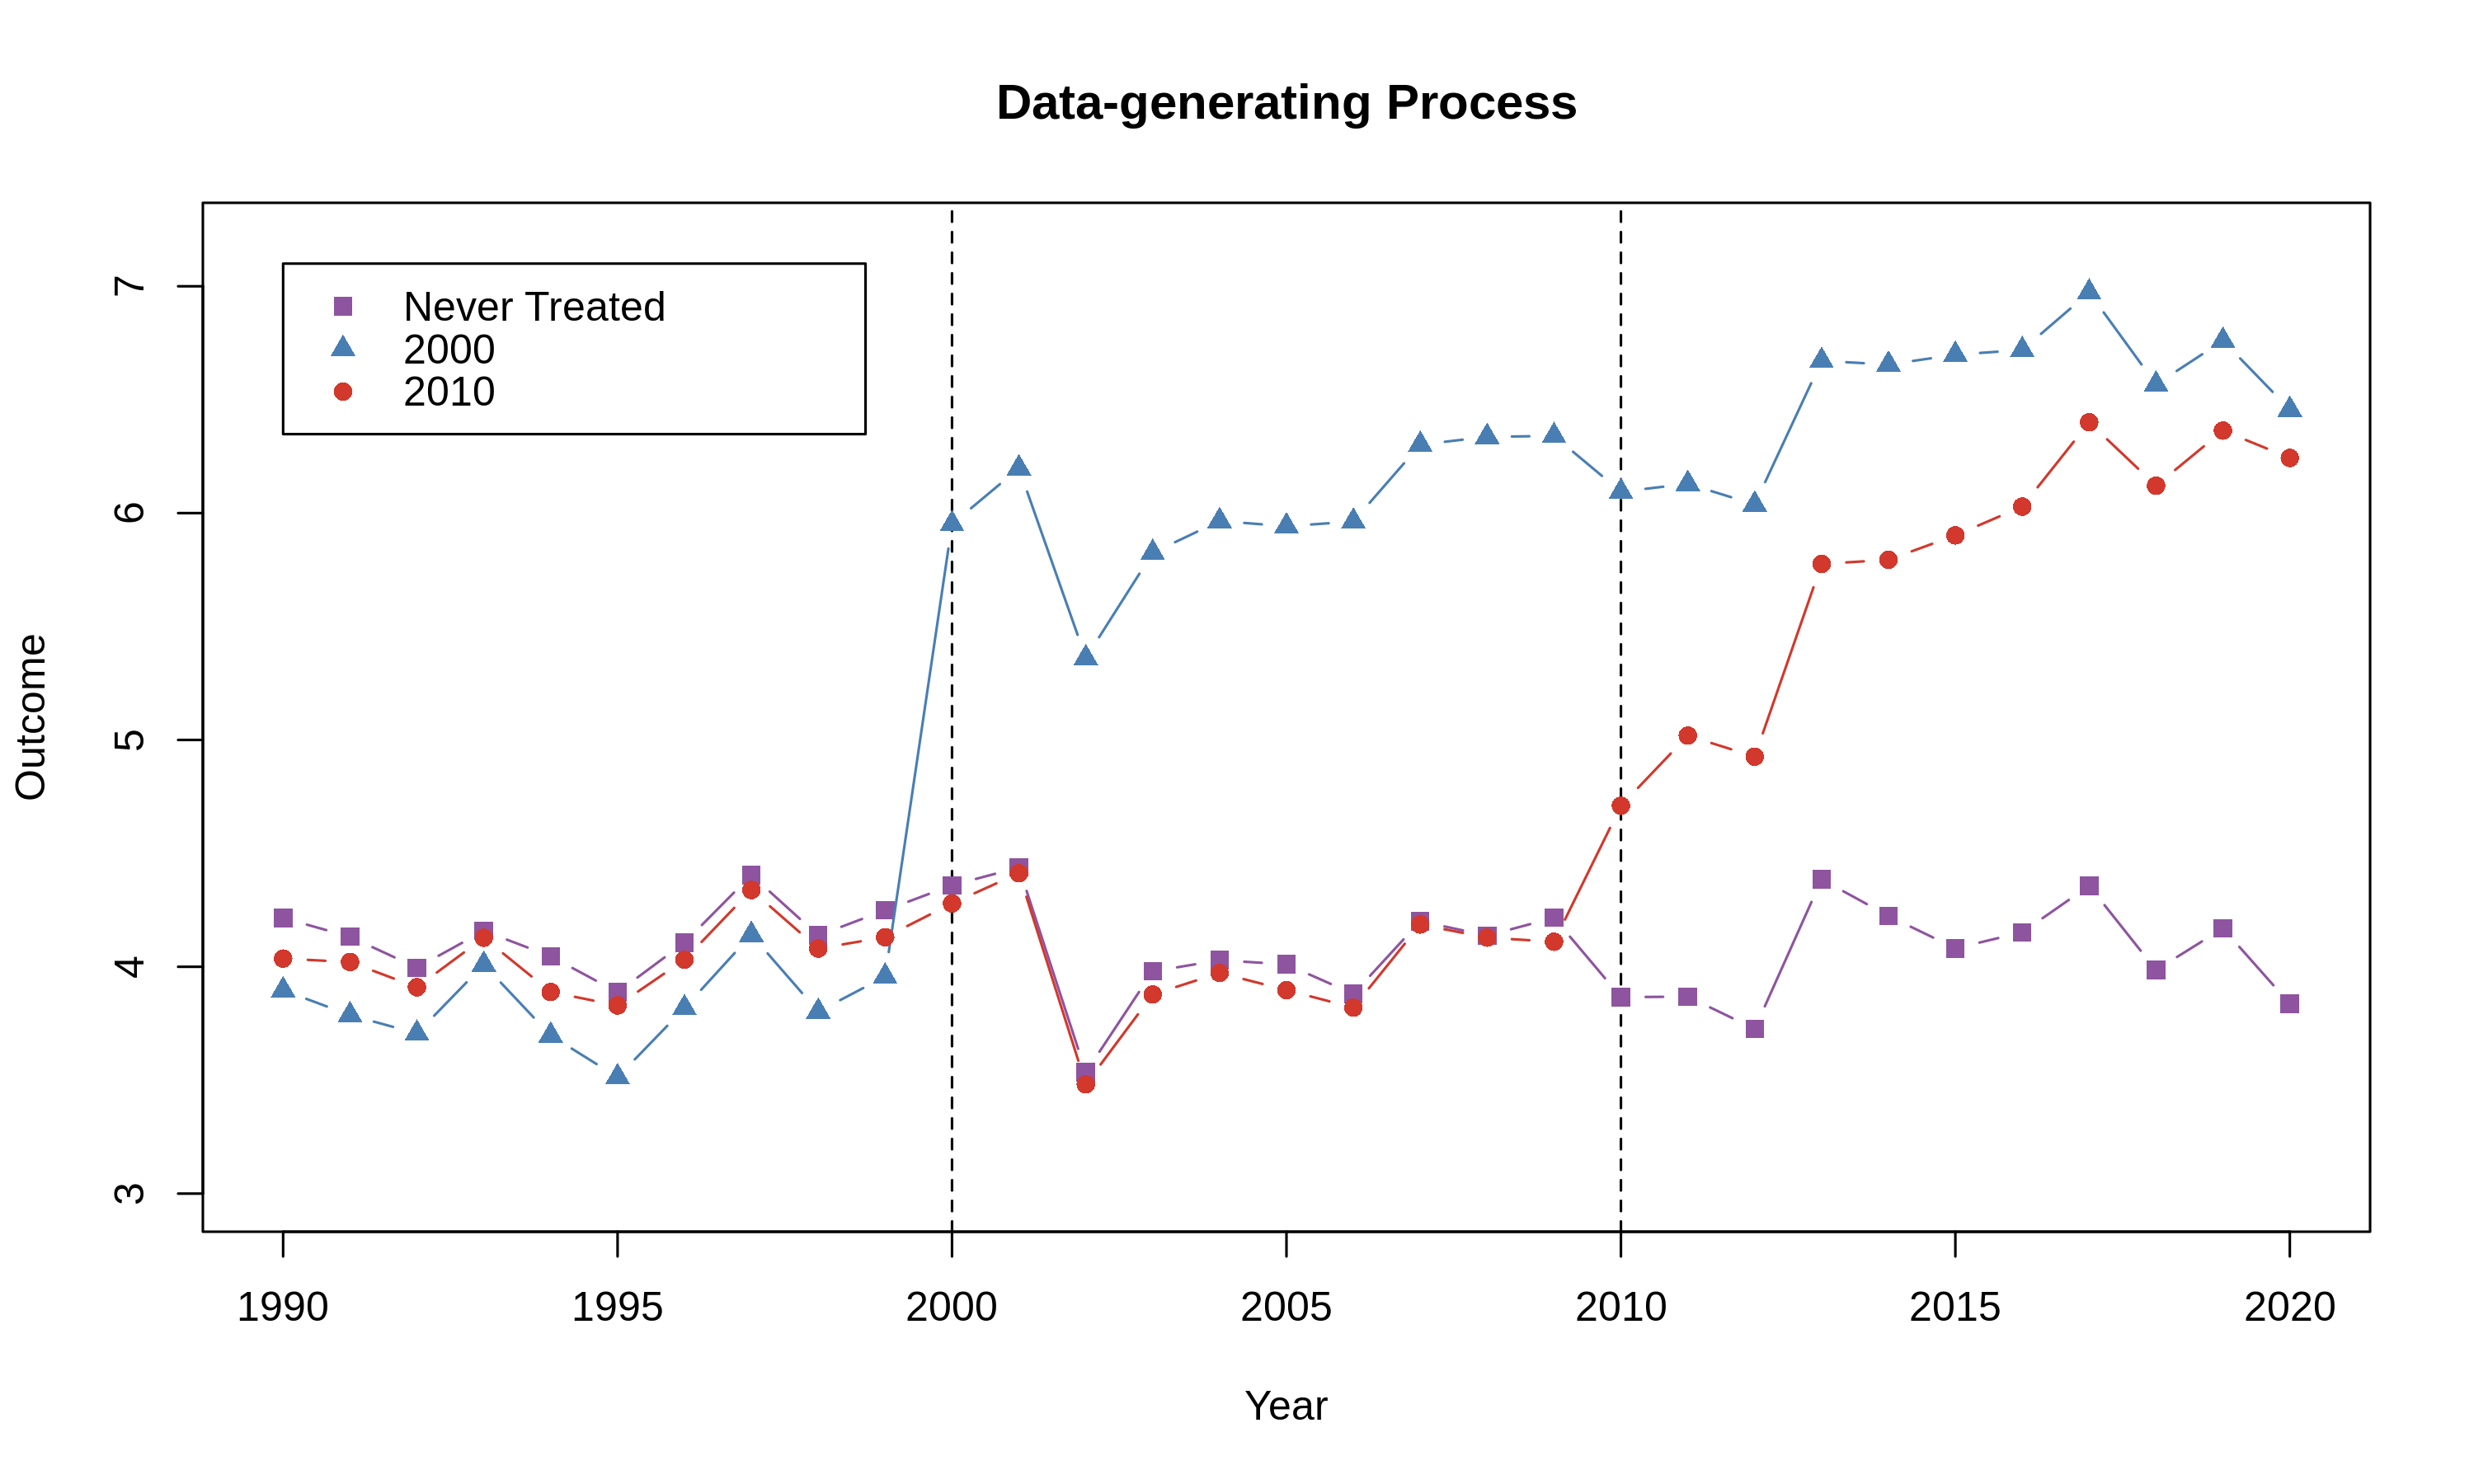

In [6]:
# @title Plot the mean for treatment group-year

# Aggregate the dependent variable by group and year, calculating the mean for each combination
agg <- aggregate(df_het$dep_var, by=list(g = df_het$g, year = df_het$year), FUN = mean)

# Convert the group variable to character type
agg$g <- as.character(agg$g)

# Replace "0" with "Never Treated" in the group variable
agg$g <- ifelse(agg$g == "0", "Never Treated", agg$g)

# Subset the data for different groups
never <- agg[agg$g == "Never Treated", ] # Never Treated group
g1 <- agg[agg$g == "2000", ]            # Group treated in 2000
g2 <- agg[agg$g == "2010", ]            # Group treated in 2010

# Create an empty plot with specified limits and labels
plot(0, 0, xlim = c(1990,2020), ylim = c(3,7.2), type = "n",
     main = "Data-generating Process", ylab = "Outcome", xlab = "Year")

# Add vertical dashed lines at the treatment years
abline(v = c(2000, 2010), lty = 2)

# Plot the lines for each group with different colors and point types
lines(never$year, never$x, col = "#8e549f", type = "b", pch = 15) # Never Treated group
lines(g1$year, g1$x, col = "#497eb3", type = "b", pch = 17)      # Group treated in 2000
lines(g2$year, g2$x, col = "#d2382c", type = "b", pch = 16)      # Group treated in 2010

# Add a legend to the plot
legend(x=1990, y=7.1, col = c("#8e549f", "#497eb3", "#d2382c"),
       pch = c(15, 17, 16),
       legend = c("Never Treated", "2000", "2010"))

### Estimate Two-stage Difference-in-Differences

In [7]:
# Perform a static difference-in-differences (DiD) analysis using the did2s function

static = did2s(
    data = df_het,                  # Specify the dataset to use
    yname = "dep_var",              # Define the dependent variable
    treatment = "treat",            # Define the treatment indicator variable
    first_stage = ~ 0 | unit + year, # Specify the fixed effects for the first stage: no intercept, unit and year fixed effects
    second_stage = ~ i(treat, ref = FALSE), # Specify the treatment indicator for the second stage. Because of the static modeling, FALSE as reference
    cluster_var = "unit",          # Cluster standard errors at the state level
    verbose = FALSE                 # Disable verbose output
)

# Display the results of the DiD analysis using fixest package's esttable function
fixest::esttable(static)

,,static
,<chr>,<chr>
1,Dependent Var.:,dep_var
2,,
3,treat = TRUE,2.230*** (0.0214)
4,_______________,_________________
5,S.E. type,Custom
6,Observations,"46,500"
7,R2,0.50568
8,Adj. R2,0.50568


Very close to the true treatment effect of 2.23.

In [8]:
# Conduct an event study analysis using the did2s function

es = did2s(
  data = df_het,                  # Use the specified dataset
  yname = "dep_var",              # Dependent variable
  treatment = "treat",            # Treatment indicator variable
  first_stage = ~ 0 | unit + year, # First stage fixed effects: no intercept, unit and year fixed effects
  second_stage = ~ i(rel_year, ref = c(-1, Inf)), # Second stage: interaction term for relative year, using -1 and Inf (never treated) as reference levels
  cluster_var = "unit",          # Cluster standard errors by state
  verbose = FALSE                 # Disable verbose output
)

# Present the results of the event study analysis with the fixest package's esttable function
fixest::esttable(es)

,,es
,<chr>,<chr>
1,Dependent Var.:,dep_var
2,,
3,rel_year = -20,-0.0582. (0.0345)
4,rel_year = -19,-0.0060 (0.0339)
5,rel_year = -18,-0.0062 (0.0343)
6,rel_year = -17,-0.0125 (0.0350)
7,rel_year = -16,-0.0347 (0.0354)
8,rel_year = -15,0.0378 (0.0348)
9,rel_year = -14,0.0002 (0.0338)


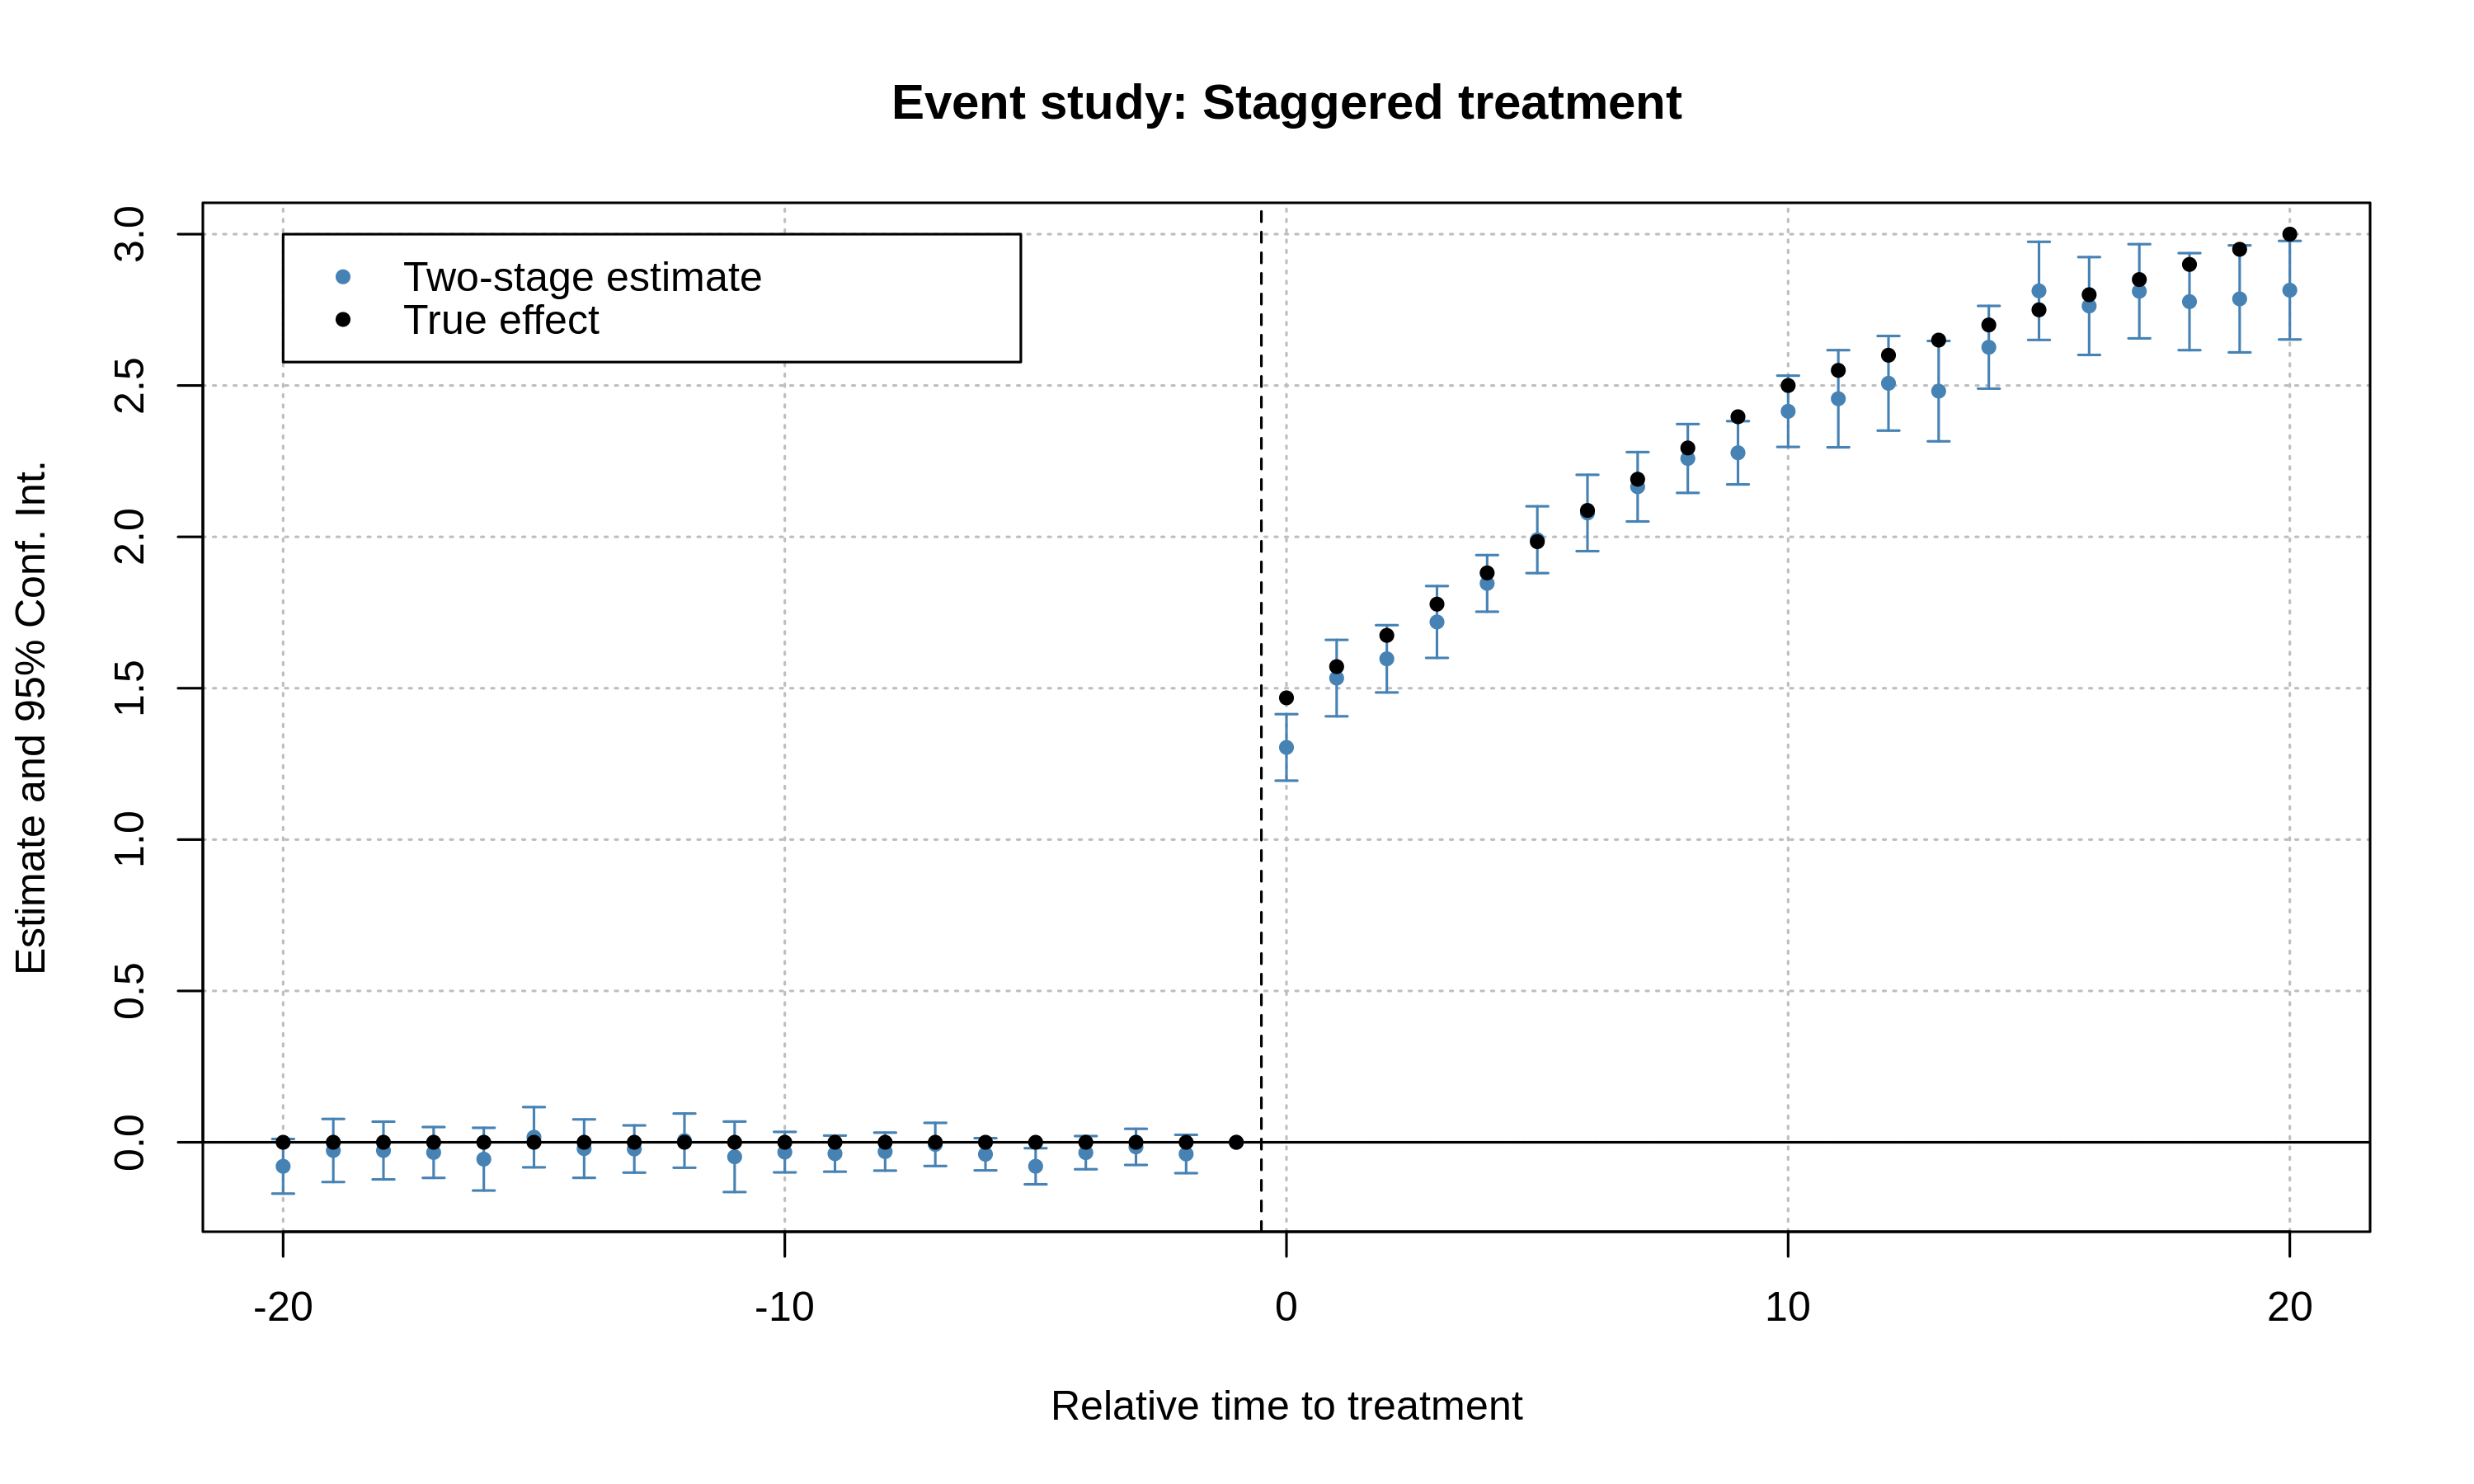

In [ ]:
# Plot the event study results using fixest's iplot function

fixest::iplot(
  es,                              # Use the event study results from the did2s function
  main = "Event study: Staggered treatment", # Title of the plot
  xlab = "Relative time to treatment",       # Label for the x-axis
  col = "steelblue",               # Color of the plot lines
  ref.line = -0.5                  # Position of the reference line on the y-axis
)

# Add the (mean) true effects to the plot
true_effects = head(tapply((df_het$te + df_het$te_dynamic), df_het$rel_year, mean), -1) # Calculate mean true effects by relative year, excluding the last element
points(-20:20, true_effects, pch = 20, col = "black") # Plot the true effects as black points

# Add a legend to the plot
legend(x=-20, y=3, col = c("steelblue", "black"), # Define legend items with colors
       pch = c(20, 20), # Define legend items with point types
       legend = c("Two-stage estimate", "True effect")) # Legend labels


### Compare with TWFE

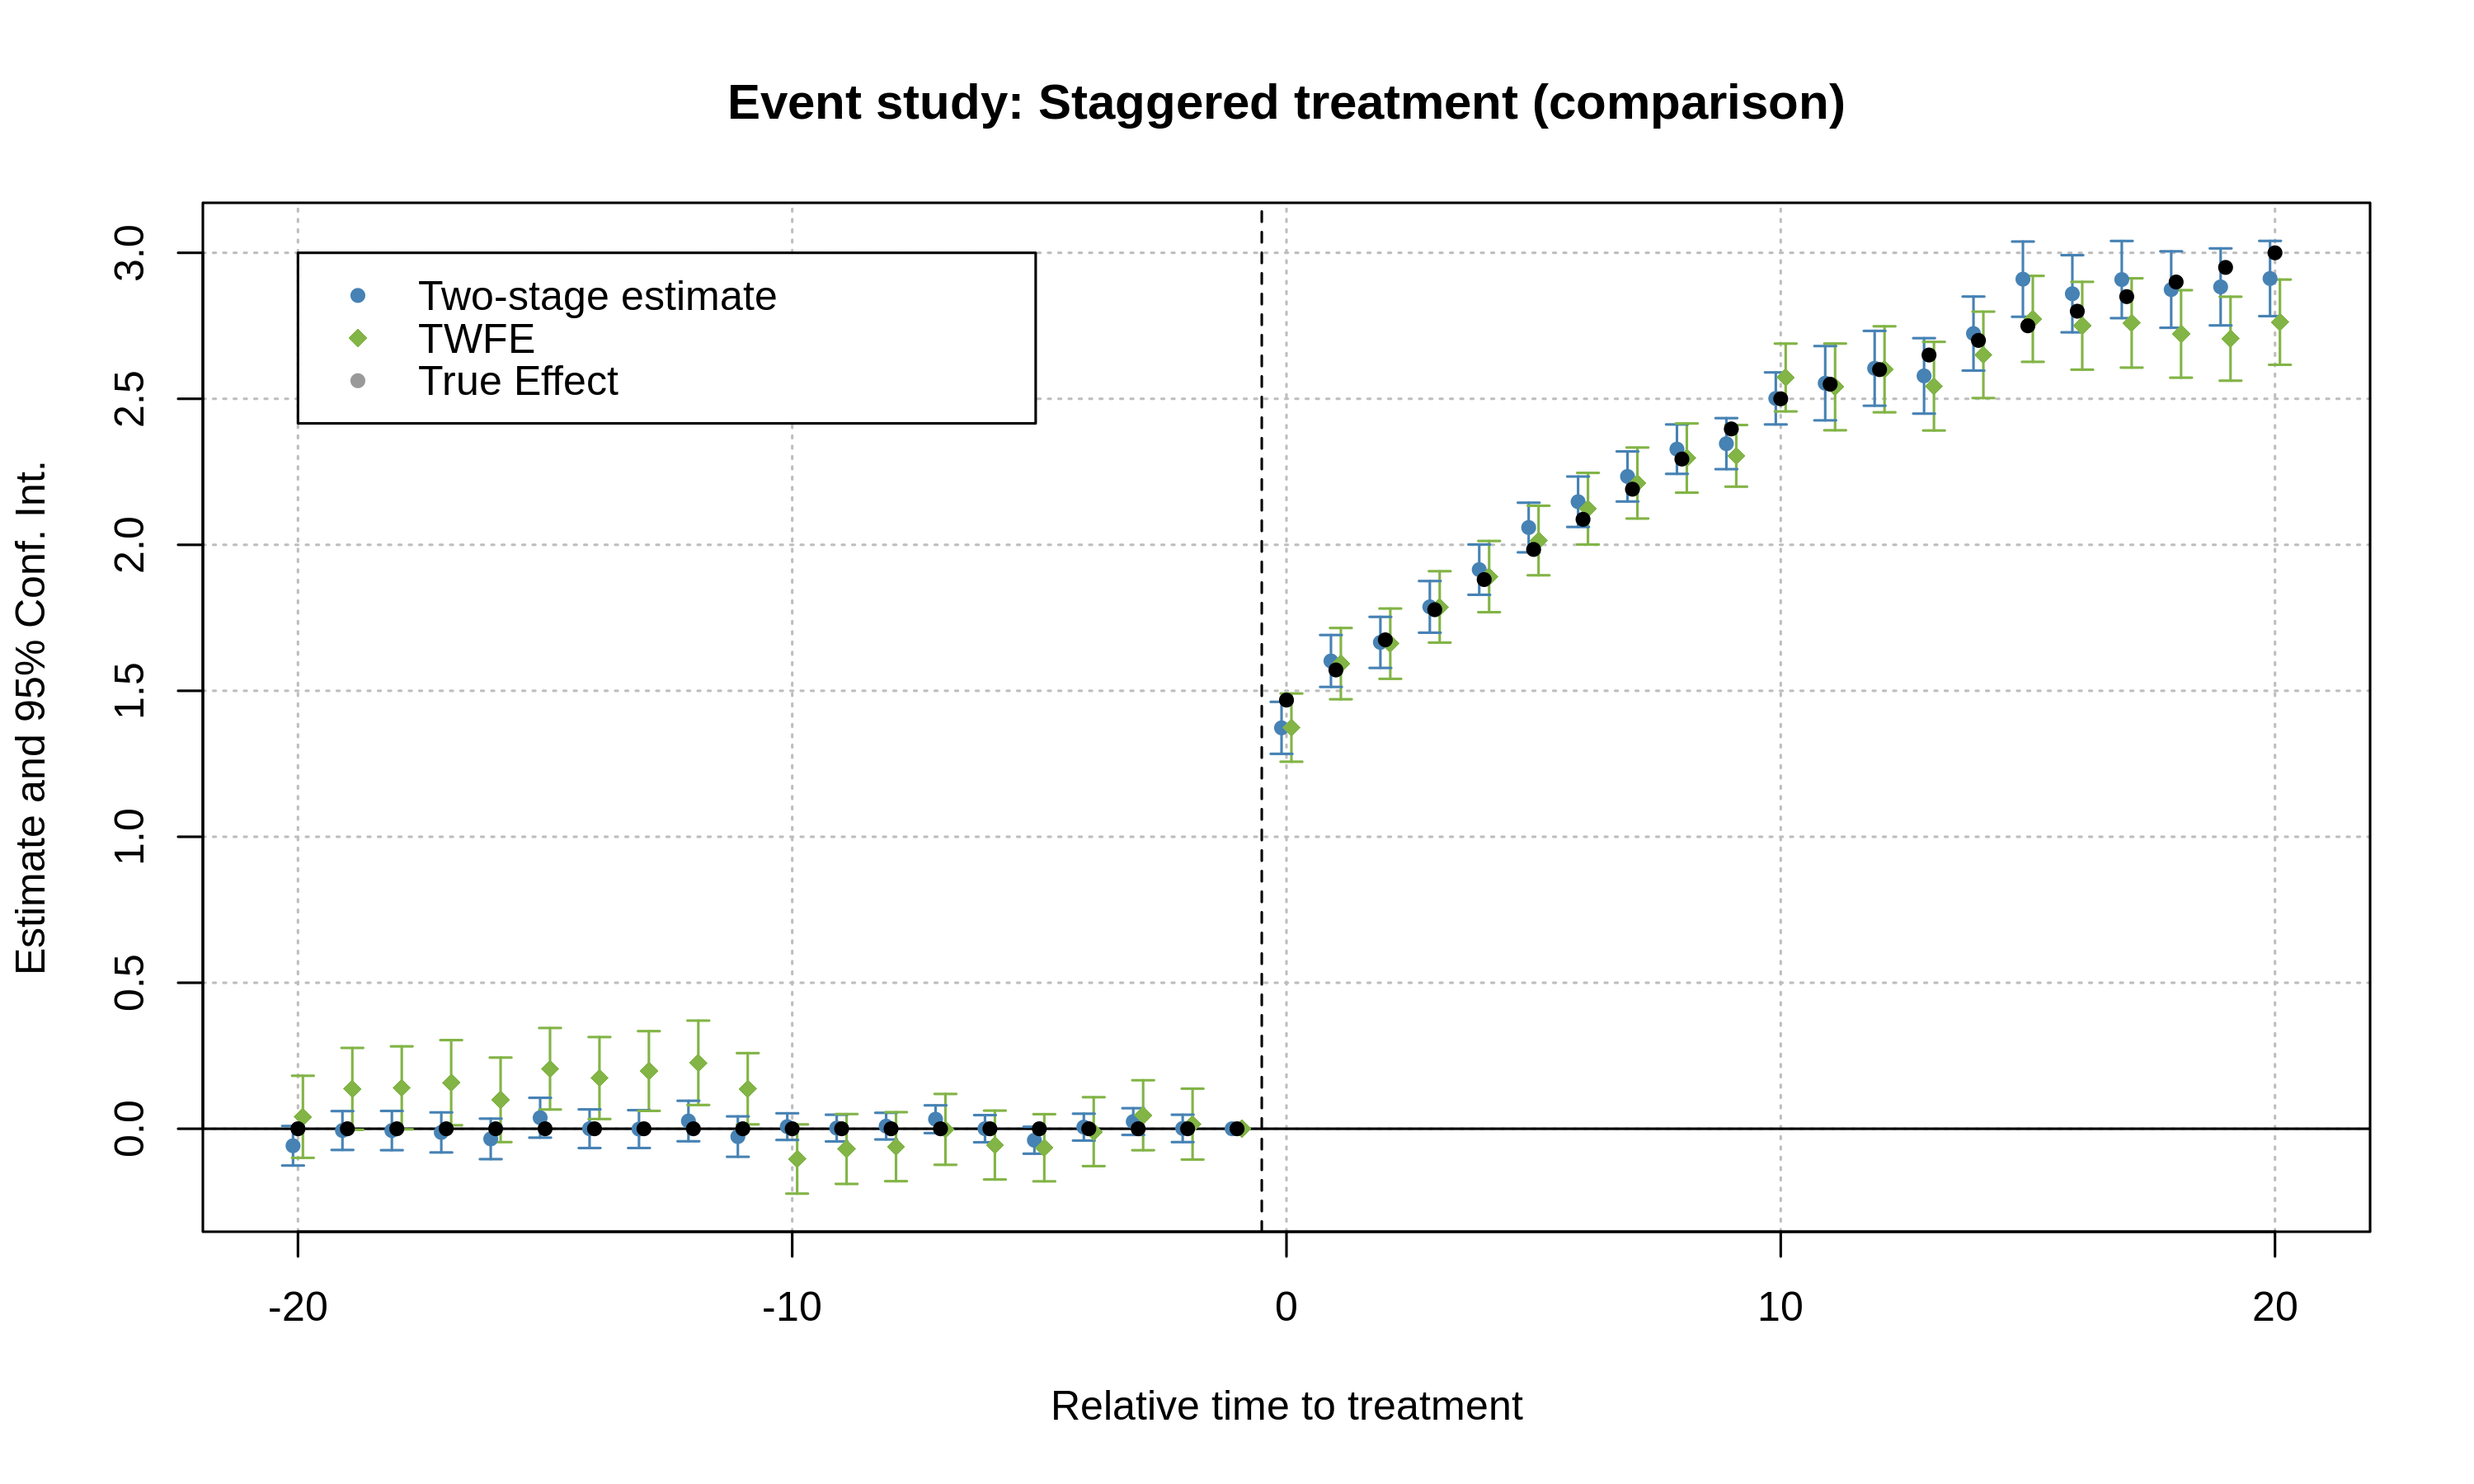

In [13]:
twfe = feols(dep_var ~ i(rel_year, ref=c(-1, Inf)) | unit + year, data = df_het)

fixest::iplot(list(es, twfe), sep = 0.2, ref.line = -0.5,
      col = c("steelblue", "#82b446"), pt.pch = c(20, 18),
      xlab = "Relative time to treatment",
      main = "Event study: Staggered treatment (comparison)")

# True Effects
true_effects = head(tapply((df_het$te + df_het$te_dynamic), df_het$rel_year, mean), -1) # Calculate mean true effects by relative year, excluding the last element
points(-20:20, true_effects, pch = 20, col = "black")

# Legend
legend(x=-20, y=3, col = c("steelblue", "#82b446", "grey60"), pch = c(20, 18, 20),
       legend = c("Two-stage estimate", "TWFE", "True Effect"))

### Compare with other estimators

In [11]:
# Load the sample dataset df_het from the did2s package
data(df_het, package = "did2s")

# Perform an event study analysis using the event_study function
out = event_study(
  data = df_het,          # Specify the dataset to use
  yname = "dep_var",      # Define the dependent variable
  idname = "unit",        # Define the unit identifier variable
  tname = "year",         # Define the time variable (year)
  gname = "g",            # Define the group variable indicating treatment time
  estimator = "all"       # Use all available estimators for the event study
)

# Display the first few rows of the event study results
head(out)

Note these estimators rely on different underlying assumptions. See Table 2 of `https://arxiv.org/abs/2109.05913` for an overview.

Estimating TWFE Model

Estimating using Gardner (2021)

Estimating using Callaway and Sant'Anna (2020)

Estimating using Sun and Abraham (2020)

Estimating using Borusyak, Jaravel, Spiess (2021)

Estimating using Roth and Sant'Anna (2021)



estimator,term,estimate,std.error
<chr>,<dbl>,<dbl>,<dbl>
TWFE,-20,0.04097725,0.07167704
TWFE,-19,0.13665695,0.07147683
TWFE,-18,0.14015820,0.07245520
TWFE,-17,0.15793252,0.07431871
TWFE,-16,0.09910002,0.07379570
TWFE,-15,0.20561127,0.07116478


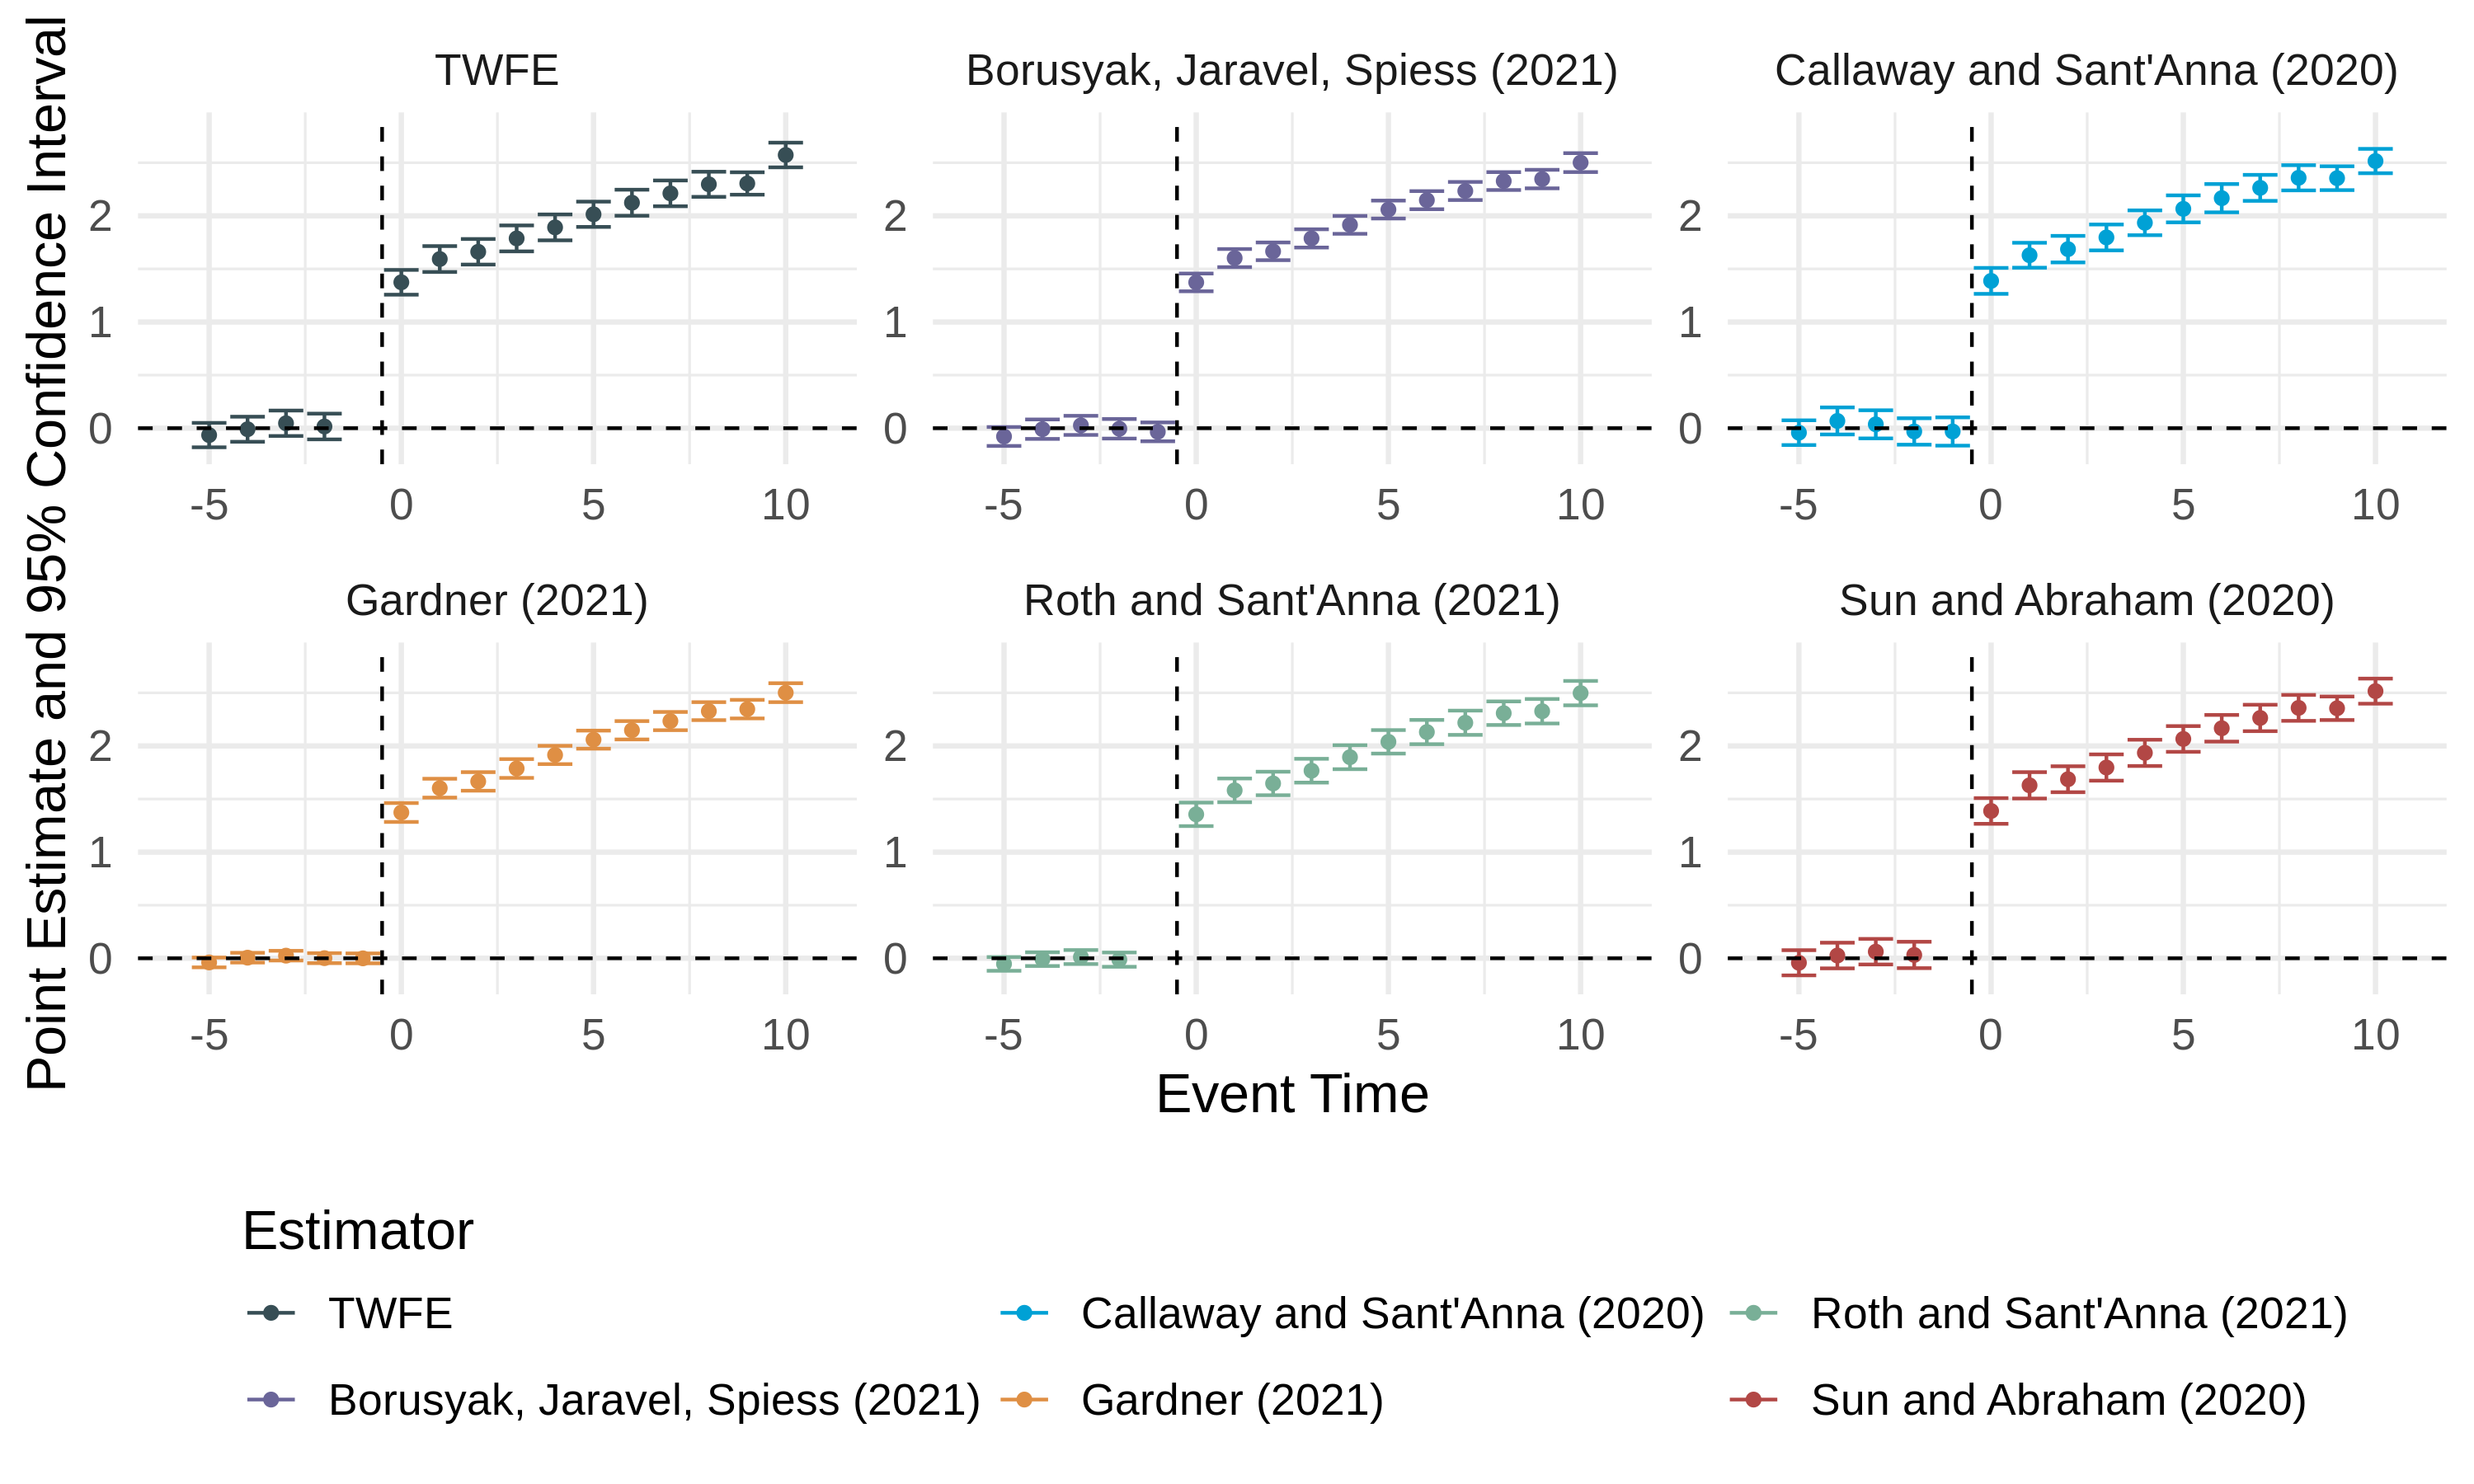

In [12]:
# Plot the event study results using the plot_event_study function

plot_event_study(
  out,                     # Use the event study results stored in the variable 'out'
  horizon = c(-5, 10)      # Specify the time horizon for the plot, from 5 years before to 10 years after the event
)


### Stata code

```
*Ref: https://github.com/kylebutts/did2s_stata
ssc install did2s

* Import data
use "https://github.com/kylebutts/did2s_stata/raw/main/data/df_het.dta", clear
xtset unit year
xtsum dep_var treat unit state g year rel_year te

* Manual calculation (note: standard errors are wrong)
qui reg dep_var i.state i.year if treat == 0
predict adj, residuals
reg adj i.treat, cluster(state) nocons

* Using the did2s package (note: standard errors are fine)
did2s dep_var, first_stage(i.state i.year) second_stage(i.treat) treatment(treat) cluster(state)

* Event study style (note: rescale the data and modify the second equation)
* (Let us rescale the data because we cannot have negatives in a factor variable)
gen     rel_year_shift = rel_year + 20
replace rel_year_shift = 100 if rel_year_shift == .

did2s dep_var, first_stage(i.state i.year) second_stage(ib100.rel_year_shift) treatment(treat) cluster(state)


********************************************************************************
* Another example with covariates: Castle Doctrine
********************************************************************************
** Setup
cls
clear all
macro drop _all

* Import data
use "https://github.com/scunning1975/mixtape/raw/master/castle.dta", clear

* Define Covariates
global demo blackm_15_24 whitem_15_24 blackm_25_44 whitem_25_44

* No Covariates
did2s l_homicide [aweight=popwt], first_stage(i.sid i.year) second_stage(i.post) treatment(post) cluster(sid)

* With covariates
did2s l_homicide [aweight=popwt], first_stage(i.sid i.year $demo) second_stage(i.post) treatment(post) cluster(sid)
```

## References

1. Bergé, Laurent. 2018. "Efficient Estimation of Maximum Likelihood Models with Multiple Fixed-Effects: The R Package FENmlm." *CREA Discussion Papers*, no. 13.

2. Borusyak, Kirill, Xavier Jaravel, and Jann Spiess. 2021. "Revisiting Event Study Designs: Robust and Efficient Estimation." Working Paper.

3. Butts, Kyle. 2021. *Didimputation: Difference-in-Differences Estimator from Borusyak, Jaravel, and Spiess (2021)*. [https://www.github.com/kylebutts/didimputation](https://www.github.com/kylebutts/didimputation).

4. Caetano, Carolina, Brantly Callaway, Stroud Payne, and Hugo Sant’Anna Rodrigues. 2022. "Difference in Differences with Time-Varying Covariates." Working Paper. [http://arxiv.org/abs/2020.02903](http://arxiv.org/abs/2020.02903).

5. Callaway, Brantly, and Pedro H. C. Sant’Anna. 2020. "Difference-in-Differences with Multiple Time Periods." *Journal of Econometrics*. [https://doi.org/10.1016/j.jeconom.2020.12.001](https://doi.org/10.1016/j.jeconom.2020.12.001).

6. ———. 2021. *Did: Difference in Differences*. [https://bcallaway11.github.io/did/](https://bcallaway11.github.io/did/).

7. Chaisemartin, Clément de, and Xavier D’Haultfoeuille. 2019. "Two-Way Fixed Effects Estimators with Heterogeneous Treatment Effects." w25904. National Bureau of Economic Research. [https://doi.org/10.3386/w25904](https://doi.org/10.3386/w25904).

8. Frisch, Ragnar, and Frederick V. Waugh. 1933. "Partial Time Regressions as Compared with Individual Trends." *Econometrica* 1 (4): 387–401. [http://www.jstor.org/stable/1907330](http://www.jstor.org/stable/1907330).

9. Gardner, John. 2022. "Two-Stage Difference in Differences." arXiv. [https://doi.org/10.48550/arXiv.2207.02452](https://doi.org/10.48550/arXiv.2207.02452).

10. Goodman-Bacon, Andrew. 2018. "Difference-in-Differences with Variation in Treatment Timing." w25018. National Bureau of Economic Research. [https://doi.org/10.3386/w25018](https://doi.org/10.3386/w25018).

11. Imbens, Guido W., and Donald B. Rubin. 2015. "Large Sample Estimation and Hypothesis Testing." In *Handbook of Econometrics*, edited by Z. Griliches and M. D. Intriligator, 4:2111–2245. Elsevier. [https://EconPapers.repec.org/RePEc:eee:econom:v:4:y:1986:i:c:p:2111-2245](https://EconPapers.repec.org/RePEc:eee:econom:v:4:y:1986:i:c:p:2111-2245).

12. Robinson, David, Alex Hayes, and Eryn Cook. 2021. *Broom: Convert Statistical Objects into Tidy Tibbles*. [https://CRAN.R-project.org/package=broom](https://CRAN.R-project.org/package=broom).

13. Roth, Jonathan. 2022. "Pre-Test with Caution: Event-Study Estimates After Testing for Parallel Trends." American Economic Review: Insights. [https://doi.org/10.1257/aeri.20210326](https://doi.org/10.1257/aeri.20210326).

14. Sun, Liyang, and Sarah Abraham. 2020. "Estimating Dynamic Treatment Effects in Event Studies with Heterogeneous Treatment Effects." *Journal of Econometrics*, December. [https://doi.org/10.1016/j.jeconom.2020.09.006](https://doi.org/10.1016/j.jeconom.2020.09.006).

15. Wickham, Hadley. 2016. *Ggplot2: Elegant Graphics for Data Analysis*. Springer-Verlag New York. [https://ggplot2.tidyverse.org](https://ggplot2.tidyverse.org).
